# Plots of simulated clusters and the data around them

## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gaianir_open_clusters.config import RESULTS_DIRECTORY
from gaianir_open_clusters.gaia_nir_config import SIMULATION_FINAL_MAGNITUDE_LIMITS
from gaianir_open_clusters import plots
from gaianir_open_clusters.util import add_gaia_dr3_uncertainties_based_on_sampling

plots.setup_matplotlib(no_log=True)

In [2]:
detection_results = pd.read_parquet(RESULTS_DIRECTORY / "detection_results.parquet")

## Helper

In [3]:
default_marker_kwargs = dict(alpha=0.05, ms=3, color="k")


def plot_cluster(
    region,
    members,
    mission,
    mean_pm,
    use_combined=True,
    color_members=None,
    pm_clip=2,
    figsize=(plots.TEXTWIDTH, plots.TEXTWIDTH / 2),
    **marker_kwargs,
):
    fig, ax = plt.subplots(ncols=2, figsize=figsize, layout="constrained")

    key_astrometry = mission
    if "gaianir" in mission and use_combined:
        key_astrometry = mission + "_combined"

    key_pmra = f"pmra_{key_astrometry}"
    key_pmdec = f"pmdec_{key_astrometry}"

    mission_short = mission.replace("_dr3", "").replace("_dr4", "").replace("_dr5", "")

    settings = default_marker_kwargs.copy()
    if marker_kwargs is not None:
        settings.update(marker_kwargs)

    maglim = SIMULATION_FINAL_MAGNITUDE_LIMITS[mission]

    sample_region = region.loc[
        (region[f"uncrowded_{mission_short}"])
        & (region[maglim["band"]] < maglim["limit"])
    ]
    ax[0].plot(sample_region["l"], sample_region["b"], "o", **settings)
    ax[1].plot(sample_region[key_pmra], sample_region[key_pmdec], "o", **settings)

    if color_members is not None:
        settings["color"] = color_members

    sample_members = members.loc[
        (members[mission]) & (region[maglim["band"]] < maglim["limit"])
    ]
    ax[0].plot(sample_members["l"], sample_members["b"], "o", **settings)
    ax[1].plot(sample_members[key_pmra], sample_members[key_pmdec], "o", **settings)

    # mean_pm = sample_members[key_pmra].mean(), sample_members[key_pmdec].mean()
    ax[0].set(xlabel="$l$ [deg]", ylabel="$b$ [deg]")
    ax[1].set(
        xlabel=r"$\mu_{\alpha^*}$ [mas/yr]",
        ylabel=r"$\mu_{\delta}$ [mas/yr]",
        xlim=(mean_pm[0] - pm_clip, mean_pm[0] + pm_clip),
        ylim=(mean_pm[1] - pm_clip, mean_pm[1] + pm_clip),
    )

    return fig, ax


## Example region

In [4]:
l = 300
cluster = "embedded"
distance = 4000

In [5]:
region = pd.read_parquet(RESULTS_DIRECTORY / f"regions/{l:.3f}_0.000.parquet")
members = pd.read_parquet(
    RESULTS_DIRECTORY / f"clusters/{cluster}/{l:.3f}_0.000_{distance:.3f}.parquet"
)
info = detection_results.query(
    f"cluster=='{cluster}' and l=={l} and distance=={distance}"
).iloc[0]
mean_pm = info["pmra"], info["pmdec"]

region = add_gaia_dr3_uncertainties_based_on_sampling(region, seed=10).rename(
    columns={"gaia_dr3_g": "g_effective_gaia"}
)
members = add_gaia_dr3_uncertainties_based_on_sampling(members, seed=20)
members["gaia_dr3"] = members["gaia_dr4"]

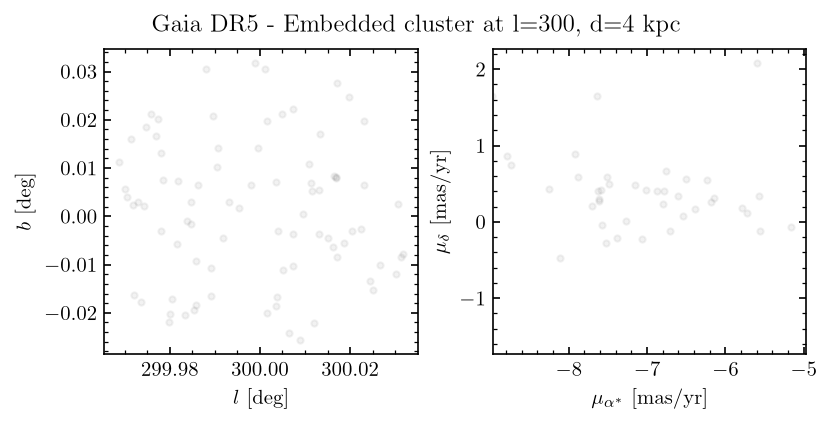

In [8]:
fig, ax = plot_cluster(
    region,
    members,
    "gaia_dr5",
    mean_pm,
    alpha=0.05,
    pm_clip=2,
    ms=3,
    figsize=(plots.TEXTWIDTH * 0.75, plots.TEXTWIDTH * 0.375),
)
ax[0].get_xaxis().get_major_formatter().set_useOffset(False)
fig.suptitle("Gaia DR5 - Embedded cluster at l=300, d=4 kpc")
fig.savefig(plots.FIGS_PRES / "example_cluster_dr5.png")

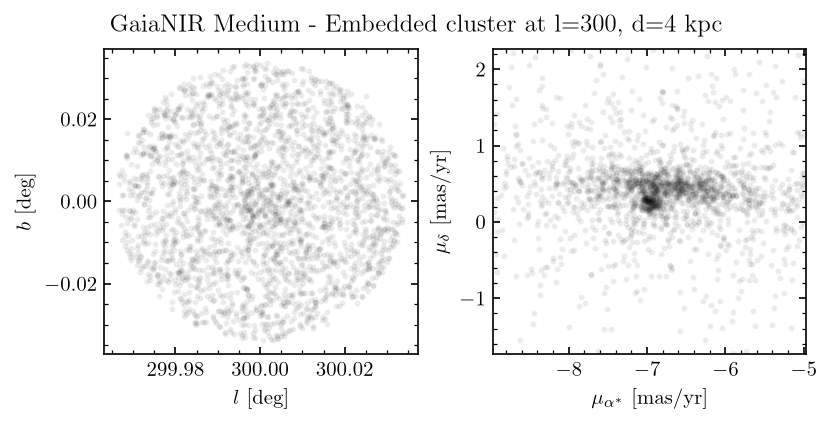

In [9]:
fig, ax = plot_cluster(
    region,
    members,
    "gaianir-m",
    mean_pm,
    alpha=0.05,
    pm_clip=2,
    ms=2,
    figsize=(plots.TEXTWIDTH * 0.75, plots.TEXTWIDTH * 0.375),
)
ax[0].get_xaxis().get_major_formatter().set_useOffset(False)
fig.suptitle("GaiaNIR Medium - Embedded cluster at l=300, d=4 kpc")
fig.savefig(plots.FIGS_PRES / "example_cluster_gaianir-m.png")

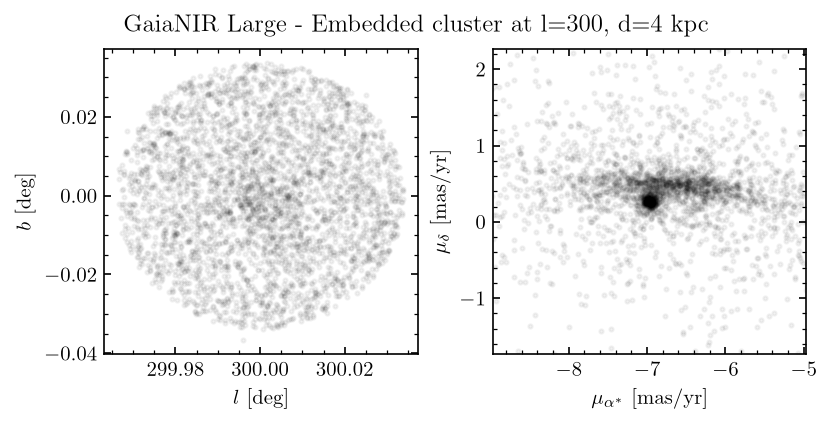

In [7]:
fig, ax = plot_cluster(
    region,
    members,
    "gaianir-l",
    mean_pm,
    alpha=0.05,
    pm_clip=2,
    ms=2,
    figsize=(plots.TEXTWIDTH * 0.75, plots.TEXTWIDTH * 0.375),
)
ax[0].get_xaxis().get_major_formatter().set_useOffset(False)
fig.suptitle("GaiaNIR Large - Embedded cluster at l=300, d=4 kpc")
fig.savefig(plots.FIGS_PRES / "example_cluster_gaianir-l.png")